# Imports

In [ ]:
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from copy import deepcopy
from tqdm import tqdm
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Load [TREC](https://drive.google.com/drive/folders/1A3BLR32oCew8zGtCK-1kaOWNQN6ul79_?usp=sharing) Dataset

In [ ]:
df_train_full = pd.read_csv("train.csv")
df_test       = pd.read_csv("test.csv")

NUM_CLASSES = 6
LABEL_NAMES = ["ABBR", "DESC", "ENTY", "HUM", "LOC", "NUM"]
print(f"Train: {len(df_train_full)}  Test: {len(df_test)}")
print("Class distribution:\n", df_train_full["label-coarse"].value_counts().sort_index())

Train: 5452  Test: 500
Class distribution:
 label-coarse
0    1162
1    1250
2      86
3    1223
4     896
5     835
Name: count, dtype: int64


# Class Distribution

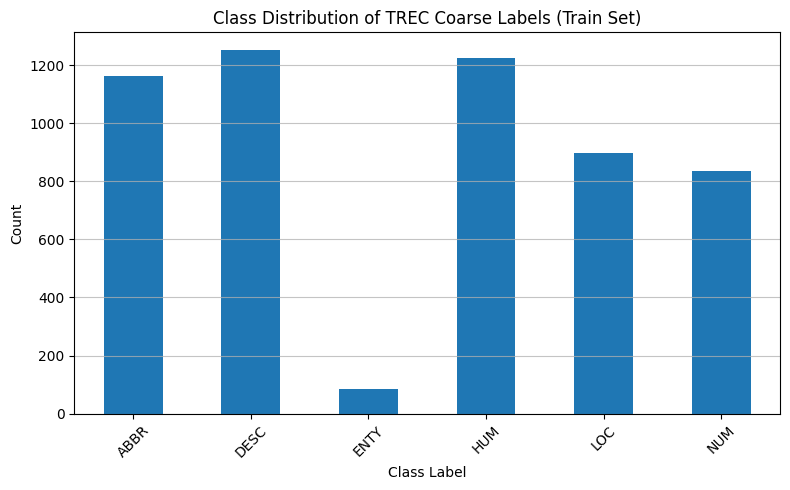

In [ ]:
plt.figure(figsize=(8, 5))
df_train_full["label-coarse"].value_counts(sort=False).plot(kind="bar")
plt.title("Class Distribution of TREC Coarse Labels (Train Set)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(ticks=range(NUM_CLASSES), labels=LABEL_NAMES, rotation=45)
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

# Text-Preprocessing

In [ ]:
QUESTION_WORDS = {"what", "who", "where", "when", "why", "how", "which", "whom", "whose"}

def is_valid_token(token, stop_words, question_words):
    """
    Accept:
      - question words always (critical for TREC)
      - pure alpha tokens not in stopwords
      - acronyms like u.s.s.r.
      - hyphenated words like yo-yos
    Reject:
      - pure punctuation, numbers, stopwords
    """
    if token in question_words:
        return True
    if token in stop_words:
        return False
    if token.isalpha():
        return True
    if re.fullmatch(r'([a-z]\.)+', token):
        return True
    if re.fullmatch(r'[a-z]+(-[a-z]+)+', token):
        return True
    return False

def text_preprocess_pipeline(text_list, max_len=32):
    stop_words = set(stopwords.words('english'))
    text_list_processed = []

    for text in tqdm(text_list, desc="Pre-processing Data"):
        text   = text.lower().strip()
        tokens = word_tokenize(text)
        cleaned_tokens = [
            token for token in tokens
            if is_valid_token(token, stop_words, QUESTION_WORDS)
        ]
        cleaned_tokens = cleaned_tokens[:max_len - 1]
        cleaned_tokens.append("<eos>")
        if len(cleaned_tokens) < max_len:
            cleaned_tokens += ["<pad>"] * (max_len - len(cleaned_tokens))
        text_list_processed.append(cleaned_tokens)

    return text_list_processed

def convert_text_to_idx(text_list_tokenized, create_vocab=True, token_to_idx=None):
    if create_vocab:
        token_to_idx = {"<pad>": 0, "<eos>": 1, "<unk>": 2}
        idx_to_token = dict([[value, key] for key, value in token_to_idx.items()])
        idx_counter = 3
    token_freq = dict([[key, 0] for key in token_to_idx.keys()])
    text_list_converted = list()

    for text_tokenized in tqdm(text_list_tokenized, desc="Generating vocab and converting to ids"):
        tokens_as_ids = list()
        for token in text_tokenized:
            if token not in token_to_idx:
                if create_vocab:
                    token_to_idx[token] = idx_counter
                    idx_to_token[idx_counter] = token
                    token_freq[token] = 1
                    idx_counter += 1
                else:
                    token = "<unk>"
                    token_freq[token] += 1
            else:
                token_freq[token] += 1
            tokens_as_ids.append(token_to_idx[token])
        text_list_converted.append(tokens_as_ids)

    if create_vocab:
        return text_list_converted, token_to_idx, idx_to_token, token_freq
    else:
        return text_list_converted, token_freq


In [ ]:
seq_len = 16

X = text_preprocess_pipeline(df_train_full["text"].tolist(), seq_len)
Y = df_train_full["label-coarse"].values

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=27,
    stratify=df_train_full["label-coarse"].values)

print("\nThe first tokenized sentence in the train set\n", X_train[0],
      "\n The total number of samples in train set", len(X_train))
print("\nThe first tokenized sentence in the validation set\n", X_val[0],
      "\n The total number of samples in validation set", len(X_val), "\n\n")

X_train, token_to_idx, idx_to_token, token_freq_train = convert_text_to_idx(
    X_train, create_vocab=True, token_to_idx=None)
X_val, token_freq_val = convert_text_to_idx(
    X_val, create_vocab=False, token_to_idx=token_to_idx)

print("\nThe first id based sentence in the train set\n",  X_train[0])
print("\nThe first id based sentence in the validation set\n", X_val[0], "\n\n")

token_freq_train = Counter(token_freq_train)
token_freq_val   = Counter(token_freq_val)
print("\n\n\nTop 10 most frequent tokens in the Train set:\n",  token_freq_train.most_common(10))
print("\n\nTop 10 most frequent tokens in the Validation set:\n", token_freq_val.most_common(10))

X_test = text_preprocess_pipeline(df_test["text"].tolist(), seq_len)
X_test, token_freq_test = convert_text_to_idx(
    X_test, create_vocab=False, token_to_idx=token_to_idx)


Pre-processing Data: 100%|██████████| 5452/5452 [00:00<00:00, 11515.27it/s]



The first tokenized sentence in the train set
 ['what', 'auto-commentary', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'] 
 The total number of samples in train set 4361

The first tokenized sentence in the validation set
 ['what', 'british', 'female', 'pop', 'singing', 'star', 'early', 'child', 'actress', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'] 
 The total number of samples in validation set 1091 




Generating vocab and converting to ids: 100%|██████████| 1091/1091 [00:00<00:00, 226388.25it/s]



The first id based sentence in the train set
 [3, 4, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

The first id based sentence in the validation set
 [3, 683, 1560, 3600, 2171, 1547, 2929, 326, 282, 1, 0, 0, 0, 0, 0, 0] 





Top 10 most frequent tokens in the Train set:
 [('<pad>', 41303), ('<eos>', 4361), ('what', 2711), ('how', 634), ('who', 490), ('many', 277), ('name', 265), ('where', 223), ('first', 153), ('when', 152)]


Top 10 most frequent tokens in the Validation set:
 [('<pad>', 10374), ('<unk>', 1115), ('<eos>', 1091), ('what', 666), ('how', 155), ('who', 124), ('name', 66), ('where', 63), ('many', 55), ('first', 46)]


Generating vocab and converting to ids: 100%|██████████| 500/500 [00:00<00:00, 169138.80it/s]


# Word Cloud Visualization

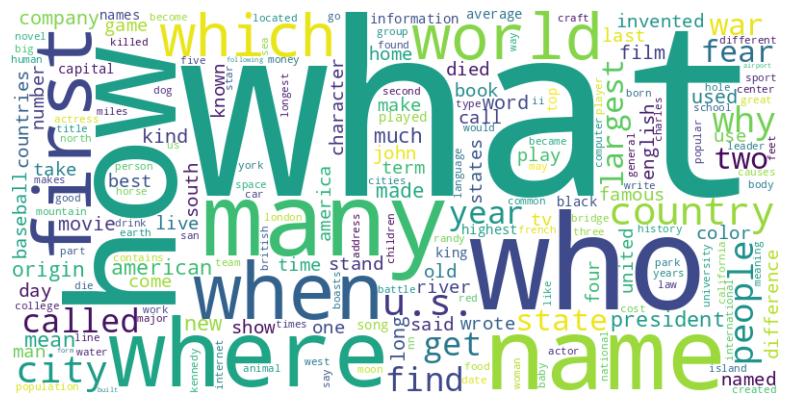

In [ ]:
tmp_token_freq_train = deepcopy(token_freq_train)
tmp_token_freq_train.pop("<pad>")
tmp_token_freq_train.pop("<eos>")
tmp_token_freq_train.pop("<unk>")
wordcloud = WordCloud(width=800, height=400, background_color="white"
                      ).generate_from_frequencies(tmp_token_freq_train)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# DataLoader

In [ ]:
PAD_IDX    = token_to_idx["<pad>"]   # 0
BATCH_SIZE = 64

class TRECDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_loader = DataLoader(TRECDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TRECDataset(X_val,   Y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TRECDataset(X_test,  df_test["label-coarse"]),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches — Train:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}")


Batches — Train:69  Val:18  Test:8


# Transformer from scratch using pytorch

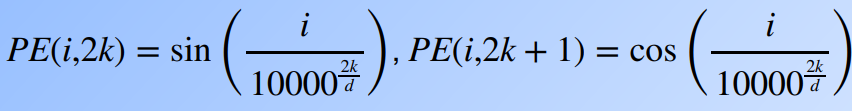

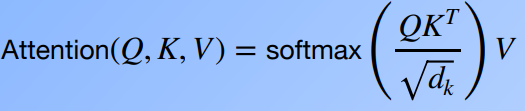

In [ ]:
import math

class EmbeddingLayer(torch.nn.Module):
    def __init__(self, d_model, vocab_size):
        super(EmbeddingLayer, self).__init__()
        self.embedding = torch.nn.Embedding(vocab_size, d_model)
        self.d_model   = d_model

    def forward(self, x):
        return self.embedding(x) * np.sqrt(self.d_model)


class PositionalEncodingLayer(torch.nn.Module):
    def __init__(self, d_model, seq_len, dropout):
        super(PositionalEncodingLayer, self).__init__()
        self.dropout = torch.nn.Dropout(p=dropout)
        pe       = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(torch.math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.dropout   = dropout
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = torch.nn.Linear(d_model, d_model)
        self.W_k = torch.nn.Linear(d_model, d_model)
        self.W_v = torch.nn.Linear(d_model, d_model)
        self.W_o = torch.nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == True, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        return torch.matmul(attn_probs, V), attn_probs

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2) #(batch, num_heads, seq_len, d_k)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        attn_output, attn_wts = self.scaled_dot_product_attention(Q, K, V, mask)
        return self.W_o(self.combine_heads(attn_output)), attn_wts


class PositionWiseFeedForward(torch.nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1     = torch.nn.Linear(d_model, d_ff)
        self.fc2     = torch.nn.Linear(d_ff, d_model)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(torch.nn.ReLU()(self.fc1(x))))


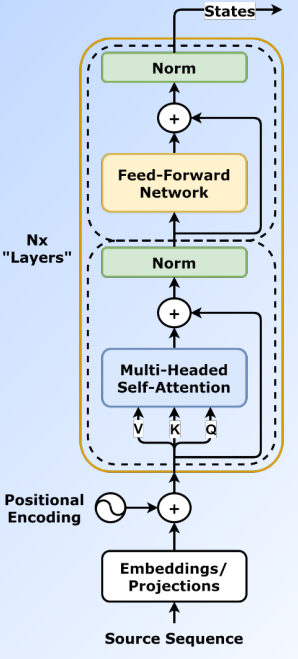

In [ ]:
class EncoderLayer(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn    = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff, dropout)
        self.norm1   = torch.nn.LayerNorm(d_model)
        self.norm2   = torch.nn.LayerNorm(d_model)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, mask):
        if isinstance(self.self_attn, torch.nn.MultiheadAttention):
            key_padding_mask = mask.squeeze(1).squeeze(1)   # (B,1,1,S) → (B,S)
            attn_output, _ = self.self_attn(x, x, x, key_padding_mask=key_padding_mask)
        else:
            attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        x = self.norm2(x + self.dropout(self.feed_forward(x)))
        return x


# Model 1(From scratch):

In [ ]:
class Transformer(torch.nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_enc_layers,
                 d_ff, seq_len, dropout, num_classes):
        super(Transformer, self).__init__()
        self.embedding           = EmbeddingLayer(d_model, vocab_size)
        self.positional_encoding = PositionalEncodingLayer(d_model, seq_len, dropout)
        self.encoder_layers      = torch.nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_enc_layers)
        ])
        self.fc      = torch.nn.Linear(d_model, num_classes)
        self.dropout = torch.nn.Dropout(dropout)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        self.criterion = torch.nn.CrossEntropyLoss()   # CE takes integer labels

    def generate_mask(self, src):
        return (src == 0).unsqueeze(1).unsqueeze(2)    # (B, 1, 1, S)

    def forward(self, src):
        src_mask = self.generate_mask(src)
        x = self.positional_encoding(self.embedding(src))
        for enc_layer in self.encoder_layers:
            x = enc_layer(x, src_mask)
        output = x.mean(dim=1)                         # mean pooling
        return self.fc(output)

    def training_step(self, batch, batch_idx):
        x, y = batch
        self.optimizer.zero_grad()
        preds = self.forward(x)
        loss  = self.criterion(preds, y)
        loss.backward()
        self.optimizer.step()
        return loss.item(), preds.detach().cpu().numpy()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        with torch.no_grad():
            preds = self.forward(x)
            loss  = self.criterion(preds, y)
        return loss.item(), preds.detach().cpu().numpy()


In [ ]:
def train(model, train_loader, val_loader, n_epochs, label="Model"):
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_loss  = float("inf")
    best_model_wts = None

    for epoch in range(n_epochs):
        # ── Train ──
        model.train()
        epoch_loss, correct, total = 0, 0, 0
        for batch_idx, (x, y) in enumerate(train_loader):
            x     = x.to(device)
            y_idx = y.to(device)
            loss, preds = model.training_step((x, y_idx), batch_idx)
            epoch_loss += loss
            correct += (torch.tensor(preds).argmax(dim=1) == y).sum().item()
            total   += x.size(0)
        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(correct / total)

        # ── Validate ──
        model.eval()
        val_loss, correct, total = 0, 0, 0
        for batch_idx, (x, y) in enumerate(val_loader):
            x     = x.to(device)
            y_idx = y.to(device)
            loss, preds = model.validation_step((x, y_idx), batch_idx)
            val_loss += loss
            correct += (torch.tensor(preds).argmax(dim=1) == y).sum().item()
            total    += x.size(0)
        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        # Save best model weights
        if val_losses[-1] < best_val_loss:
            best_val_loss  = val_losses[-1]
            best_model_wts = copy.deepcopy(model.state_dict())
            print(f"[{label}] Epoch {epoch+1:02d}/{n_epochs}  "
                  f"Loss: {train_losses[-1]:.4f}/{val_losses[-1]:.4f}  "
                  f"Acc: {train_accs[-1]*100:.1f}%/{val_accs[-1]*100:.1f}%  (*saved*)")
        else:
            print(f"[{label}] Epoch {epoch+1:02d}/{n_epochs}  "
                  f"Loss: {train_losses[-1]:.4f}/{val_losses[-1]:.4f}  "
                  f"Acc: {train_accs[-1]*100:.1f}%/{val_accs[-1]*100:.1f}%")

    model.load_state_dict(best_model_wts)   # restore best weights
    return train_losses, val_losses, train_accs, val_accs

def plot_metrics(train_losses, val_losses, train_accs, val_accs, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label="Train", marker="o", markersize=3)
    ax1.plot(val_losses,   label="Val",   marker="s", markersize=3)
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot([a*100 for a in train_accs], label="Train", marker="o", markersize=3)
    ax2.plot([a*100 for a in val_accs],   label="Val",   marker="s", markersize=3)
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [ ]:
# Hyperparameters
vocab_size     = len(token_to_idx)
d_model        = 64
num_heads      = 2
num_enc_layers = 4
d_ff           = 128
dropout        = 0.4
n_epochs       = 70

print(f"vocab={vocab_size}  d_model={d_model}  heads={num_heads}  "
      f"layers={num_enc_layers}  dropout={dropout}  epochs={n_epochs}")

vocab=7095  d_model=64  heads=2  layers=4  dropout=0.4  epochs=70


In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Model 1 (Custom) — Trainable Parameters: 0.588M

[Model1-Custom] Epoch 01/70  Loss: 1.4430/1.1902  Acc: 39.2%/54.5%  (*saved*)
[Model1-Custom] Epoch 02/70  Loss: 1.1746/1.0244  Acc: 52.8%/57.9%  (*saved*)
[Model1-Custom] Epoch 03/70  Loss: 1.0645/0.9115  Acc: 57.8%/61.9%  (*saved*)
[Model1-Custom] Epoch 04/70  Loss: 1.0097/0.8959  Acc: 61.8%/63.3%  (*saved*)
[Model1-Custom] Epoch 05/70  Loss: 0.9653/0.8377  Acc: 64.0%/65.6%  (*saved*)
[Model1-Custom] Epoch 06/70  Loss: 0.9271/0.7830  Acc: 64.3%/67.6%  (*saved*)
[Model1-Custom] Epoch 07/70  Loss: 0.8888/0.8152  Acc: 66.9%/65.3%
[Model1-Custom] Epoch 08/70  Loss: 0.8778/0.7682  Acc: 66.3%/67.3%  (*saved*)
[Model1-Custom] Epoch 09/70  Loss: 0.8476/0.7741  Acc: 67.3%/67.5%
[Model1-Custom] Epoch 10/70  Loss: 0.8235/0.6930  Acc: 68.6%/72.0%  (*saved*)
[Model1-Custom] Epoch 11/70  Loss: 0.7954/0.7374  Acc: 69.7%/70.9%
[Model1-Custom] Epoch 12/70  Loss: 0.7958/0.7356  Acc: 68.8%/70.6%
[Model1-Custom] Epoch 13/70  Loss: 0.7524/0.6888  Acc: 71.

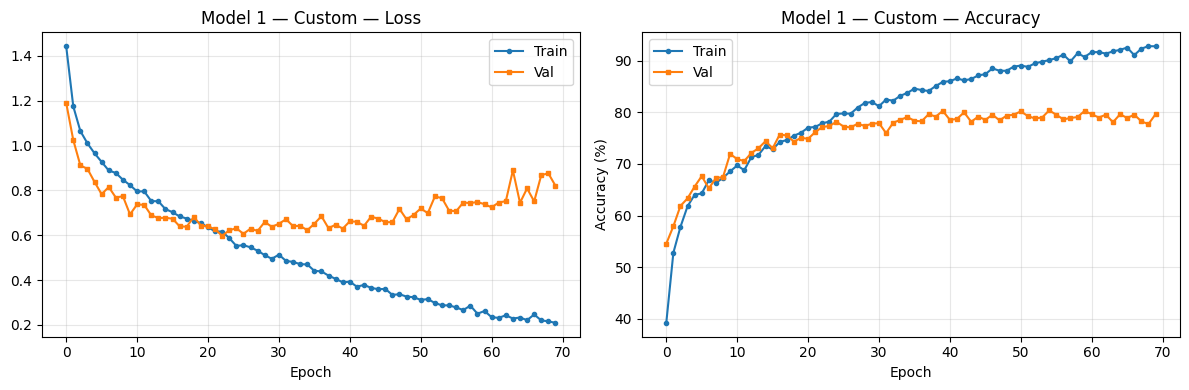

In [ ]:
model1 = Transformer(vocab_size, d_model, num_heads, num_enc_layers,
                     d_ff, seq_len, dropout, NUM_CLASSES).to(device)
print(f"\nModel 1 (Custom) — Trainable Parameters: {count_trainable_parameters(model1)/1e6:.3f}M\n")
trl1, vll1, tra1, vla1 = train(model1, train_loader, val_loader, n_epochs, "Model1-Custom")
plot_metrics(trl1, vll1, tra1, vla1, "Model 1 — Custom")


Model 2 (nn.MHA) — Trainable Parameters: 0.588M

[Model2-nn.MHA] Epoch 01/70  Loss: 1.4758/1.1570  Acc: 38.2%/53.7%  (*saved*)
[Model2-nn.MHA] Epoch 02/70  Loss: 1.2701/1.1647  Acc: 49.1%/51.4%
[Model2-nn.MHA] Epoch 03/70  Loss: 1.1767/1.0632  Acc: 53.7%/54.7%  (*saved*)
[Model2-nn.MHA] Epoch 04/70  Loss: 1.1278/1.0468  Acc: 55.4%/56.0%  (*saved*)
[Model2-nn.MHA] Epoch 05/70  Loss: 1.0746/0.9792  Acc: 57.2%/57.0%  (*saved*)
[Model2-nn.MHA] Epoch 06/70  Loss: 1.0401/0.8769  Acc: 59.5%/64.3%  (*saved*)
[Model2-nn.MHA] Epoch 07/70  Loss: 1.0110/0.8689  Acc: 60.4%/65.6%  (*saved*)
[Model2-nn.MHA] Epoch 08/70  Loss: 0.9627/0.8719  Acc: 62.9%/65.3%
[Model2-nn.MHA] Epoch 09/70  Loss: 0.9589/0.8721  Acc: 63.5%/65.1%
[Model2-nn.MHA] Epoch 10/70  Loss: 0.9285/0.7954  Acc: 64.5%/69.8%  (*saved*)
[Model2-nn.MHA] Epoch 11/70  Loss: 0.9129/0.7853  Acc: 64.5%/68.9%  (*saved*)
[Model2-nn.MHA] Epoch 12/70  Loss: 0.8996/0.8124  Acc: 66.4%/68.2%
[Model2-nn.MHA] Epoch 13/70  Loss: 0.8708/0.8459  Acc: 67.

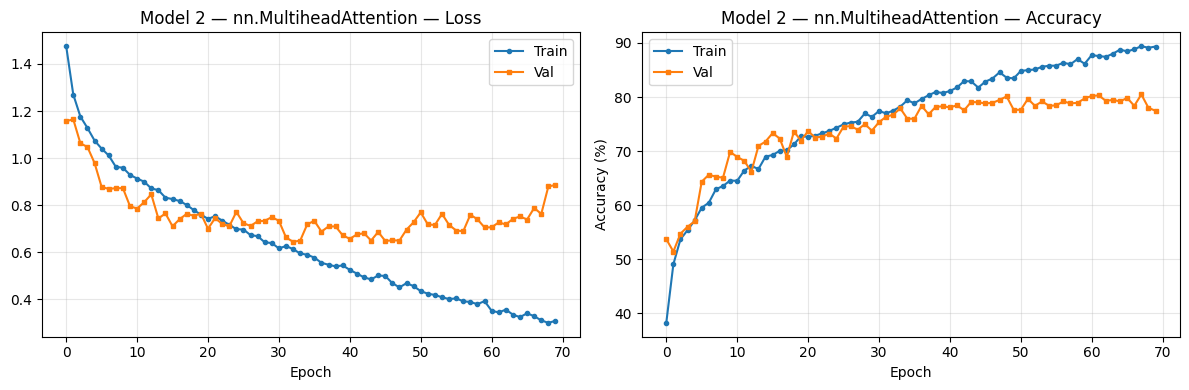

In [ ]:
model2 = Transformer(vocab_size, d_model, num_heads, num_enc_layers,
                     d_ff, seq_len, dropout, NUM_CLASSES)
for i in range(num_enc_layers):
    model2.encoder_layers[i].self_attn = torch.nn.MultiheadAttention(
        d_model, num_heads, dropout=dropout, batch_first=True)
model2.optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
model2 = model2.to(device)
print(f"\nModel 2 (nn.MHA) — Trainable Parameters: {count_trainable_parameters(model2)/1e6:.3f}M\n")
trl2, vll2, tra2, vla2 = train(model2, train_loader, val_loader, n_epochs, "Model2-nn.MHA")
plot_metrics(trl2, vll2, tra2, vla2, "Model 2 — nn.MultiheadAttention")


# Model 3 (nn.TransformerEncoder)

In [ ]:
class Transformer_nn(torch.nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_enc_layers,
                 d_ff, seq_len, dropout, num_classes):
        super(Transformer_nn, self).__init__()
        self.embedding           = EmbeddingLayer(d_model, vocab_size)
        self.positional_encoding = PositionalEncodingLayer(d_model, seq_len, dropout)
        encoder_layer = torch.nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True
        )
        self.encoder = torch.nn.TransformerEncoder(encoder_layer, num_layers=num_enc_layers)
        self.fc      = torch.nn.Linear(d_model, num_classes)
        self.dropout = torch.nn.Dropout(dropout)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        self.criterion = torch.nn.CrossEntropyLoss()

    def forward(self, src):
        src_mask = (src == 0)                          # (B, S) True at PAD
        x = self.positional_encoding(self.embedding(src))
        x = self.encoder(x, src_key_padding_mask=src_mask)
        x = torch.mean(x, dim=1)                       # mean pooling
        return self.fc(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        self.optimizer.zero_grad()
        preds = self.forward(x)
        loss  = self.criterion(preds, y)
        loss.backward()
        self.optimizer.step()
        return loss.item(), preds.detach().cpu().numpy()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        with torch.no_grad():
            preds = self.forward(x)
            loss  = self.criterion(preds, y)
        return loss.item(), preds.detach().cpu().numpy()


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Model 3 (nn.TransEnc) — Trainable Parameters: 0.588M

[Model3-nn.TransEnc] Epoch 01/120  Loss: 1.4972/1.4084  Acc: 36.9%/44.5%  (*saved*)
[Model3-nn.TransEnc] Epoch 02/120  Loss: 1.2784/1.2903  Acc: 47.0%/52.3%  (*saved*)
[Model3-nn.TransEnc] Epoch 03/120  Loss: 1.1674/1.2268  Acc: 52.2%/55.2%  (*saved*)
[Model3-nn.TransEnc] Epoch 04/120  Loss: 1.1120/1.1819  Acc: 55.4%/55.0%  (*saved*)
[Model3-nn.TransEnc] Epoch 05/120  Loss: 1.0862/1.1314  Acc: 56.7%/55.5%  (*saved*)
[Model3-nn.TransEnc] Epoch 06/120  Loss: 1.0187/1.1146  Acc: 60.2%/55.1%  (*saved*)
[Model3-nn.TransEnc] Epoch 07/120  Loss: 1.0006/1.0566  Acc: 62.0%/57.4%  (*saved*)
[Model3-nn.TransEnc] Epoch 08/120  Loss: 0.9787/1.0472  Acc: 62.2%/58.0%  (*saved*)
[Model3-nn.TransEnc] Epoch 09/120  Loss: 0.9670/1.0741  Acc: 63.3%/52.0%
[Model3-nn.TransEnc] Epoch 10/120  Loss: 0.9332/0.9906  Acc: 64.1%/61.6%  (*saved*)
[Model3-nn.TransEnc] Epoch 11/120  Loss: 0.9012/1.0196  Acc: 66.3%/58.8%
[Model3-nn.TransEnc] Epoch 12/120  Loss: 0.

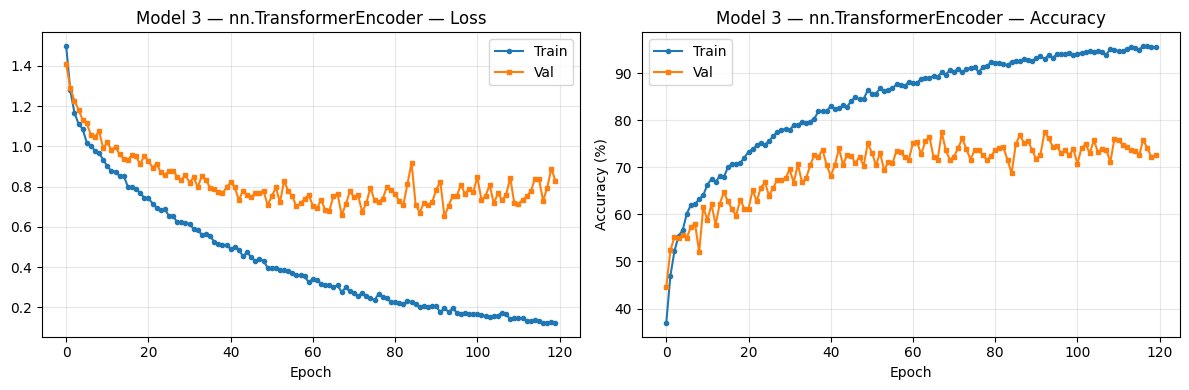

In [ ]:
model3 = Transformer_nn(vocab_size, d_model, num_heads, num_enc_layers,
                        d_ff, seq_len, dropout, NUM_CLASSES).to(device)
print(f"\nModel 3 (nn.TransEnc) — Trainable Parameters: {count_trainable_parameters(model3)/1e6:.3f}M\n")
trl3, vll3, tra3, vla3 = train(model3, train_loader, val_loader, n_epochs=120, label="Model3-nn.TransEnc")
plot_metrics(trl3, vll3, tra3, vla3, "Model 3 — nn.TransformerEncoder")


# Evaluation and Comparision

In [ ]:
def evaluate(model, loader, label="Model"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x       = x.to(device)
            preds   = model(x).argmax(dim=1).cpu()
            targets = y.argmax(dim=1)   # y is always OHE (B,6) from dataloader
            correct += (preds == targets).sum().item()
            total   += x.size(0)
    acc = correct / total
    print(f"{label}  —  Test Accuracy: {acc*100:.2f}%")
    return acc

acc1 = evaluate(model1, test_loader, "Model 1 (Custom)")
acc2 = evaluate(model2, test_loader, "Model 2 (nn.MultiheadAttention)")
acc3 = evaluate(model3, test_loader, "Model 3 (nn.TransformerEncoder)")

Model 1 (Custom)  —  Test Accuracy: 80.80%
Model 2 (nn.MultiheadAttention)  —  Test Accuracy: 81.00%
Model 3 (nn.TransformerEncoder)  —  Test Accuracy: 79.00%


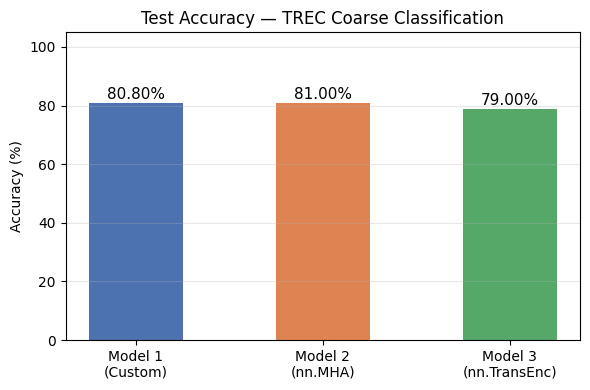

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
labels  = ["Model 1\n(Custom)", "Model 2\n(nn.MHA)", "Model 3\n(nn.TransEnc)"]
scores  = [acc1*100, acc2*100, acc3*100]
bars    = ax.bar(labels, scores, color=["#4C72B0","#DD8452","#55A868"], width=0.5)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{s:.2f}%", ha="center", va="bottom", fontsize=11)
ax.set_title("Test Accuracy — TREC Coarse Classification")
ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# Assignment 8

**Q1 [1 mark]**

The tutorial removes stopwords during preprocessing for TREC classification. For the [Multi30K](https://huggingface.co/datasets/bentrevett/multi30k/tree/main) German-to-English translation task, should stopwords be removed? Justify your answer with an example.

**Q2 [2 marks]**

For the translation task, you need separate vocabularies for source (German) and target (English). Implement text_preprocess_pipeline and convert_text_to_idx for both languages and report the vocabulary sizes.

**Q3 [6 marks]**

Design the full encoder-decoder architecture for German-to-English translation from scratch using PyTorch.

Use the following hyperparameters:

d_model        = 256

num_heads      = 8

num_enc_layers = 3

num_dec_layers = 3

d_ff           = 512

dropout        = 0.1



**Q4 [2 marks]**

Train the transformer model designed from scratch and show the variation of the training and validation losses against the number of epochs.


**Q5 [3 marks]**

Replace the custom MultiHeadAttention modules in your encoder and decoder layers with torch.nn.MultiheadAttention and train the corresponding model. Show the variation of the training and validation losses against the number of epochs

**Q6 [3 marks]**

Redesign the translation model using torch.nn.Transformer as the backbone and train the corresponding model. Show the variation of the training and validation losses against the number of e

**Q7 [3 marks]**

Evaluate all three models on the test set using BLEU score (nltk.translate.bleu_score.corpus_bleu). Present the scores in a bar chart and provide at least 3 sample translations side-by-side from all three models. Briefly discuss which model performs best and why.
